# Exercise 
1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)  

2. Plot bar charts showing impact of employee salaries on retention  

3. Plot bar charts showing corelation between department and employee retention  

4. Now build logistic regression model using variables that were narrowed down in step 1  

5. Measure the accuracy of the model

In [836]:
import pandas as pd
import os 
file = os.listdir()
df = pd.read_csv(file[2])


## Step 1: Data Understanding
* Data shape
* Head and Tail
* dtyes
* describe

In [837]:
df.shape

(14999, 10)

In [838]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [839]:
df.tail(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [840]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

In [841]:
df.salary.unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

In [842]:
df.Department.unique()

<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

## Step 2: Data Preperation
1. Remove irrelevent columns
2. Check and remove duplicate rows
3. Check for missing values
4. Verify correct data types for each column
5. Rename columns if necessary for easier use
6. Verify the cleaned dataset before analysis


In [843]:
df.duplicated().sum()

np.int64(3008)

In [844]:
df.drop_duplicates(keep= "first", inplace= True)

In [845]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

## Step 3: Feature Understanding

In [846]:
left = df[df.left == 1]
left.shape

(1991, 10)

In [847]:
retained = df[df.left == 0]
retained.shape

(10000, 10)

In [848]:
left.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [849]:
df.groupby("left").mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.667365,0.715667,3.786800,198.94270,3.262000,0.174500,0.019500
1,0.440271,0.721783,3.883476,208.16223,3.881467,0.052737,0.004018


### Insights:
* **Satisfaction Level**: Employees who left the company have significantly lower satisfaction (0.44) compared to those who stayed (0.67), making job satisfaction the strongest indicator of employee retention.
* **Average Monthly Hours**: Employees who left tend to work noteably more hours(208 vs 199), indicating that a heavier workload directly contributes to burnout and attrition.
* **Promotion in Last 5 Years**: Employees who received promotions are far more likely to stay, showing that clear career growth and advancement strongly improve retention.
* **Overall**: Employee attrition is basically driven by a combination of low workplace satisfaction, higher operational workloads and a distinct lack of promotion oppotunities.


In [850]:
import matplotlib.pyplot as plt
import seaborn as sns

###  Impact of employee salaries on retention

<Axes: xlabel='salary', ylabel='count'>

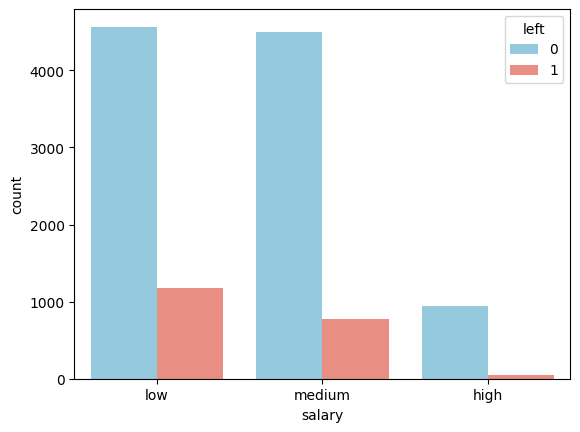

In [851]:
sns.countplot(data=df, x="salary", hue="left", palette = ["skyblue", "salmon"])

### Insights:
* **Low & Medium Salaries** : Employees with low and medium salary brackets show the vast majority of company's workforce and show significant numbers of departures.
* **High Salaries**: Employees in the high salary are highly stable. The number of high-earning individuals who left is exceptionally small compared to those who stayed.

### Corelation between department and employee retention

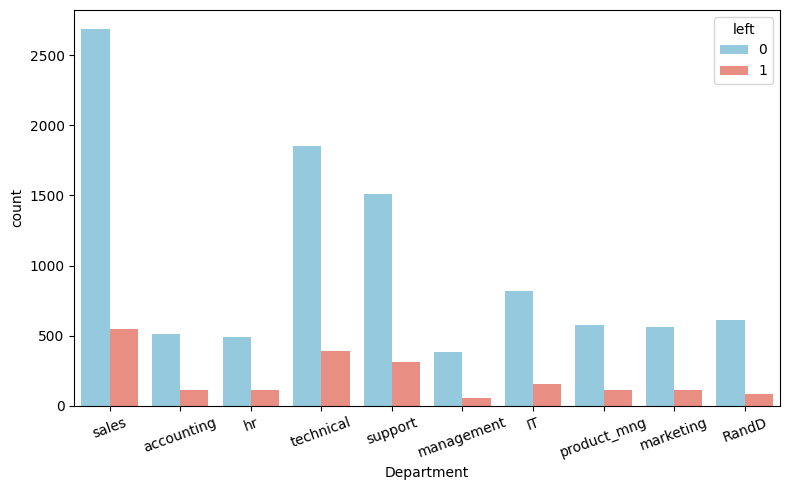

In [852]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Department", hue="left", palette = ["skyblue", "salmon"])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Insights:
1. Sales has largest workforce
* The **Sales** department has the highest number of employees
* It also has the highest number of employees who left (red bars)
2. Technical and Support also have many resignations
* **Technical** and **Support** are the next largest departments.
* They also show relatively high numbers of employees leaving.
3. Management hast the fewest resignations
* The **Management** department has very few employees leaving compared with those staying.
4. Most employees stay
* In every department, the **blue bar(Stayed)** is much taller than the red bar (left).

In [853]:
df_dummy = pd.get_dummies(df, columns=["salary"], dtype = int)
df_dummy

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,sales,0,1,0
1,0.80,0.86,5,262,6,0,1,0,sales,0,0,1
2,0.11,0.88,7,272,4,0,1,0,sales,0,0,1
3,0.72,0.87,5,223,5,0,1,0,sales,0,1,0
4,0.37,0.52,2,159,3,0,1,0,sales,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,1,0,0
11996,0.74,0.95,5,266,10,0,0,1,management,1,0,0
11997,0.85,0.54,3,185,10,0,0,1,management,1,0,0
11998,0.33,0.65,3,172,10,0,0,1,marketing,1,0,0


In [854]:
df_dummy = df_dummy.drop(columns=[
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company",
    "Work_accident",
    "left",
    "Department"
])

In [855]:
X =df_dummy

In [856]:
y = df.left

In [857]:
from sklearn.model_selection import train_test_split

In [858]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [859]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()


In [860]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [861]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 0], shape=(3598,))

In [862]:
model.score(X_test, y_test)

0.8521400778210116